# Loan Approval Prediction

**Goal:** Build a machine learning classifier to predict loan default risk using customer financial profiles, and translate model outputs into actionable business decisions.

---

## Table of Contents

1. [Problem Statement](#1-problem-statement)
2. [Dataset](#2-dataset)
3. [Setup & Data Loading](#3-setup--data-loading)
4. [Exploratory Data Analysis](#4-exploratory-data-analysis)
5. [Feature Engineering & Preprocessing](#5-feature-engineering--preprocessing)
6. [Model Training & Comparison](#6-model-training--comparison)
7. [Threshold Analysis](#7-threshold-analysis)
8. [Best Model Evaluation](#8-best-model-evaluation)
9. [Feature Importance & SHAP](#9-feature-importance--shap)
10. [Expected Loss Model](#10-expected-loss-model)
11. [Results & Business Insights](#11-results--business-insights)

---
## 1. Problem Statement

Lenders face two competing risks when evaluating loan applications:

- **Approving a defaulter** → direct financial loss
- **Rejecting a good borrower** → missed revenue

This project builds a binary classifier to estimate the **probability of default (PD)** per customer. The model supports three business strategies via adjustable classification thresholds:

| Strategy | Threshold | Priority |
|---|---|---|
| Conservative | 0.35 | Maximize recall — catch all defaulters |
| Balanced | 0.50 | Balance precision and recall (F1) |
| Aggressive | 0.85 | Maximize precision — approve more customers |

### Key Challenges

- **Class imbalance:** Non-defaulters occur ~6× more frequently than defaulters. Standard accuracy is therefore a misleading metric.
- **Asymmetric misclassification cost:** A false negative (missed defaulter) is typically more costly than a false positive (rejected good customer), depending on the business context.

---
## 2. Dataset

**Source:** [Kaggle — Playground Series S4E10](https://www.kaggle.com/competitions/playground-series-s4e10)

- **Rows:** 58,645 (train) 
- **Features:** 12 input features + 1 target
- **Target:** `loan_status` → `1` = default (reject), `0` = no default (approve)

| Column | Type | Description |
|---|---|---|
| `person_age` | numeric | Applicant age |
| `person_income` | numeric | Annual income |
| `person_emp_length` | numeric | Years employed |
| `loan_amnt` | numeric | Requested loan amount |
| `loan_int_rate` | numeric | Interest rate |
| `loan_percent_income` | numeric | Loan-to-income ratio |
| `loan_grade` | ordinal | Credit grade (A–G) |
| `loan_intent` | nominal | Purpose of loan |
| `person_home_ownership` | nominal | RENT / OWN / MORTGAGE |
| `cb_person_default_on_file` | binary | Prior default on record (Y/N) |
| `cb_person_cred_hist_length` | numeric | Credit history length (years) |
| **`loan_status`** | **binary** | **Target: 1 = default, 0 = repaid** |

---
## 3. Setup & Data Loading

In [3]:
# Install Kaggle hub to download competition data
!pip install kagglehub --quiet

In [4]:
import kagglehub

path = kagglehub.competition_download('playground-series-s4e10')
print("Downloaded to:", path)

C:\Python3.13.6\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: C:\Users\prant\.cache\kagglehub\competitions\playground-series-s4e10


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score,
    recall_score, f1_score, average_precision_score,
    confusion_matrix
)
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings('ignore')

In [6]:
train_df = pd.read_csv('train.csv')
test_df  = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
train_df.head()

Train shape: (58645, 13)
Test shape:  (39098, 12)


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


---
## 4. Exploratory Data Analysis

Before modelling, we inspect the data for:
- Schema and data types
- Outliers in numeric features
- Cardinality of categorical features
- Target class distribution

In [7]:
# Schema overview
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [8]:
# Check for extreme outliers in key numeric columns
for col in ['person_income', 'person_age', 'person_emp_length']:
    print(f"{col:30s}  min={train_df[col].min():>10,.0f}  "
          f"avg={train_df[col].mean():>10,.0f}  "
          f"max={train_df[col].max():>10,.0f}")

person_income                   min=     4,200  avg=    64,046  max= 1,900,000
person_age                      min=        20  avg=        28  max=       123
person_emp_length               min=         0  avg=         5  max=       123


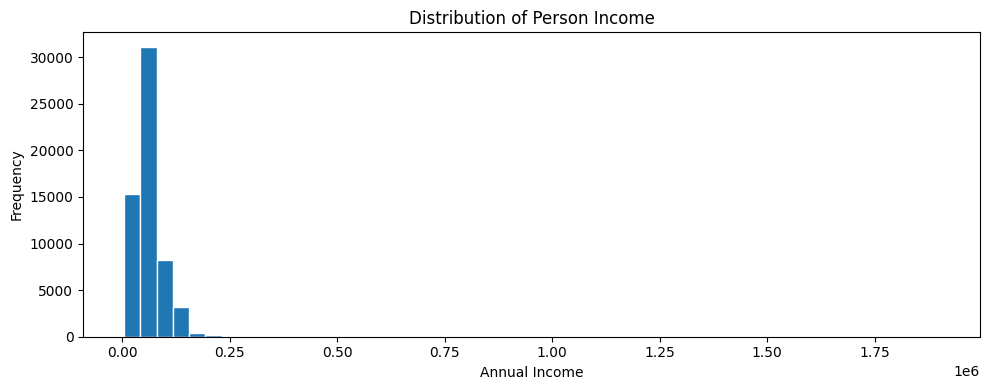


Row(s) with maximum income:


,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
17387,17387,22,1900000,MORTGAGE,6.0,EDUCATION,D,1500,15.62,0.0,Y,3,0


In [9]:
# Income distribution — check for extreme outliers
plt.figure(figsize=(10, 4))
plt.hist(train_df['person_income'], bins=50, edgecolor='white')
plt.xlabel('Annual Income')
plt.ylabel('Frequency')
plt.title('Distribution of Person Income')
plt.tight_layout()
plt.show()

# Inspect the maximum income row — likely an outlier
print("\nRow(s) with maximum income:")
train_df[train_df['person_income'] == train_df['person_income'].max()]

In [10]:
# Cardinality and unique values for categorical features
for col in ['loan_status', 'loan_intent', 'loan_grade', 'person_home_ownership', 'cb_person_default_on_file']:
    print(f"{col}: {train_df[col].unique().tolist()}")

loan_status: [0, 1]
loan_intent: ['EDUCATION', 'MEDICAL', 'PERSONAL', 'VENTURE', 'DEBTCONSOLIDATION', 'HOMEIMPROVEMENT']
loan_grade: ['B', 'C', 'A', 'D', 'E', 'F', 'G']
person_home_ownership: ['RENT', 'OWN', 'MORTGAGE', 'OTHER']
cb_person_default_on_file: ['N', 'Y']


Class 0 (No Default): 50,295
Class 1 (Default):    8,350
Imbalance ratio:      6.0x


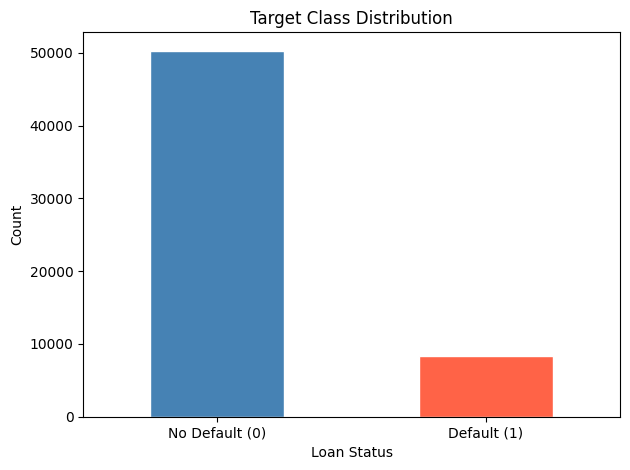

In [11]:
# Target class distribution — quantify the imbalance
counts = train_df['loan_status'].value_counts()
ratio  = counts[0] / counts[1]

print(f"Class 0 (No Default): {counts[0]:,}")
print(f"Class 1 (Default):    {counts[1]:,}")
print(f"Imbalance ratio:      {ratio:.1f}x")

counts.plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title('Target Class Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Default (0)', 'Default (1)'], rotation=0)
plt.tight_layout()
plt.show()

---
## 5. Feature Engineering & Preprocessing

### Strategy

**Interaction features** capture relationships between financial variables:
- `income_to_emp_length` — income per year of employment (earning stability)
- `income_to_age` — income relative to career stage
- `loan_amt_times_int_rate` — total repayment burden proxy

**Decile binning** reduces the impact of outliers and captures non-linear effects in continuous variables. Each numeric feature is binned into deciles using `qcut`.

**Encoding:**
- One-hot encoding for nominal categoricals (`home_ownership`, `loan_intent`, `default_on_file`)
- Label encoding for ordinal `loan_grade` (A=0 … G=6)

In [12]:
def preprocess_data(df):
    """
    Apply feature engineering and encoding to a loan dataframe.

    Steps:
      1. Interaction features (income/emp_length, income/age, loan*rate)
      2. Decile binning for all continuous features
      3. One-hot encoding for nominal categoricals
      4. Label encoding for ordinal loan_grade
      5. Drop original raw columns and rows with nulls

    Parameters
    ----------
    df : pd.DataFrame  — raw train or test dataframe

    Returns
    -------
    pd.DataFrame  — fully preprocessed dataframe ready for modelling
    """
    df = df.copy()

    if 'id' in df.columns:
        df.set_index('id', inplace=True)

    # --- Interaction features ---
    df['income_to_emp_length']    = df['person_income'] / df['person_emp_length'].replace(0, 1)
    df['income_to_age']           = df['person_income'] / df['person_age']
    df['loan_amt_times_int_rate'] = df['loan_amnt'] * df['loan_int_rate']

    # --- Decile binning (percentile-based) ---
    def safe_qcut(series, q=10):
        """qcut with fallback to equal-width cut when duplicate bin edges exist."""
        try:
            return pd.qcut(series, q=q, labels=False, duplicates='drop') + 1
        except ValueError:
            return pd.cut(series, bins=q, labels=False, duplicates='drop') + 1

    for col, alias in [
        ('person_age',                 'age_decile'),
        ('person_income',              'income_decile'),
        ('person_emp_length',          'emp_length_decile'),
        ('loan_percent_income',        'loan_percent_income_decile'),
        ('loan_amnt',                  'loan_amnt_decile'),
        ('loan_int_rate',              'loan_int_rate_decile'),
        ('cb_person_cred_hist_length', 'cb_person_cred_hist_length_decile'),
    ]:
        df[alias] = safe_qcut(df[col])

    # --- One-hot encoding for nominal categoricals ---
    df = pd.get_dummies(
        df,
        columns=['person_home_ownership', 'loan_intent', 'cb_person_default_on_file'],
        drop_first=True,
        dtype=int
    )

    # --- Label encoding for ordinal loan_grade (A=0 ... G=6) ---
    le = LabelEncoder()
    df['loan_grade_encoded'] = le.fit_transform(df['loan_grade'])

    # --- Drop original raw columns (replaced by engineered versions) ---
    cols_to_drop = [
        'person_age', 'person_income', 'person_emp_length',
        'loan_grade', 'loan_amnt', 'loan_int_rate',
        'loan_percent_income', 'cb_person_cred_hist_length'
    ]
    df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
    df.dropna(inplace=True)

    return df

In [13]:
preprocessed_train_df = preprocess_data(train_df)
preprocessed_test_df  = preprocess_data(test_df)

print(f"Train after preprocessing: {preprocessed_train_df.shape}")
preprocessed_train_df.head()

Train after preprocessing: (58645, 21)


,loan_status,income_to_emp_length,income_to_age,loan_amt_times_int_rate,age_decile,income_decile,emp_length_decile,loan_percent_income_decile,loan_amnt_decile,loan_int_rate_decile,...,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,cb_person_default_on_file_Y,loan_grade_encoded
id,,,,,,,,,,,,,,,,,,,,,
0,0,35000.000000,945.945946,68940.0,10,2,1,6,4,6,...,0,0,1,1,0,0,0,0,0,1
1,0,9333.333333,2545.454545,53400.0,1,5,6,2,2,8,...,0,1,0,0,0,1,0,0,0,2
2,0,3600.000000,993.103448,53400.0,7,1,8,8,4,4,...,0,1,0,0,0,0,1,0,0,0
3,0,5000.000000,2333.333333,133320.0,8,7,9,6,8,6,...,0,0,1,0,0,0,0,1,0,1
4,0,30000.000000,2727.272727,41520.0,1,6,2,3,4,2,...,0,0,1,0,0,1,0,0,0,0


In [14]:
# Separate features and target
X = preprocessed_train_df.drop('loan_status', axis=1)
y = preprocessed_train_df['loan_status']

# Scale features (required for Logistic Regression; neutral for tree models)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Stratified train/validation split — preserves class ratio
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}  |  Validation: {X_val.shape}")
print(f"Defaulter rate in train: {y_train.mean():.2%}")

Train: (46916, 20)  |  Validation: (11729, 20)
Defaulter rate in train: 14.24%


---
## 6. Model Training & Comparison

We train four classifiers and evaluate them at the default threshold (0.5).

**Why these models?**
- `LogisticRegression` — linear baseline with `class_weight='balanced'` to handle imbalance
- `RandomForest` — ensemble of decision trees, robust to outliers
- `GradientBoosting` — sequential boosting, strong on tabular data
- `XGBoost` — regularised gradient boosting, typically best on structured data

**Primary metric:** ROC-AUC (threshold-agnostic ranking performance).  
Accuracy is not used due to class imbalance — a trivial "always predict 0" model would score ~85%.

In [15]:
models = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",   # upweight minority class
        random_state=42
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    )
}

In [16]:
results = []

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train, y_train)

    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]

    results.append({
        "Model":     name,
        "ROC-AUC":   round(roc_auc_score(y_val, y_prob), 4),
        "PR-AUC":    round(average_precision_score(y_val, y_prob), 4),
        "Accuracy":  round(accuracy_score(y_val, y_pred), 4),
        "Precision": round(precision_score(y_val, y_pred), 4),
        "Recall":    round(recall_score(y_val, y_pred), 4),
        "F1":        round(f1_score(y_val, y_pred), 4),
    })
    print(f"ROC-AUC = {results[-1]['ROC-AUC']:.4f}")

results_df = pd.DataFrame(results).set_index("Model")

Training LogisticRegression... ROC-AUC = 0.8849
Training RandomForest... ROC-AUC = 0.9249
Training GradientBoosting... ROC-AUC = 0.9326
Training XGBoost... ROC-AUC = 0.9364


In [17]:
results_df

,ROC-AUC,PR-AUC,Accuracy,Precision,Recall,F1
Model,,,,,,
LogisticRegression,0.8849,0.6342,0.7967,0.3972,0.8269,0.5366
RandomForest,0.9249,0.8217,0.9465,0.9008,0.7018,0.7890
GradientBoosting,0.9326,0.8262,0.9419,0.8628,0.7042,0.7755
XGBoost,0.9364,0.8350,0.9455,0.8856,0.7090,0.7875


---
## 7. Threshold Analysis

The default threshold of 0.5 is rarely optimal when classes are imbalanced. Here we sweep thresholds from 0.05 to 0.90 for all models to understand the precision–recall tradeoff and guide threshold selection.

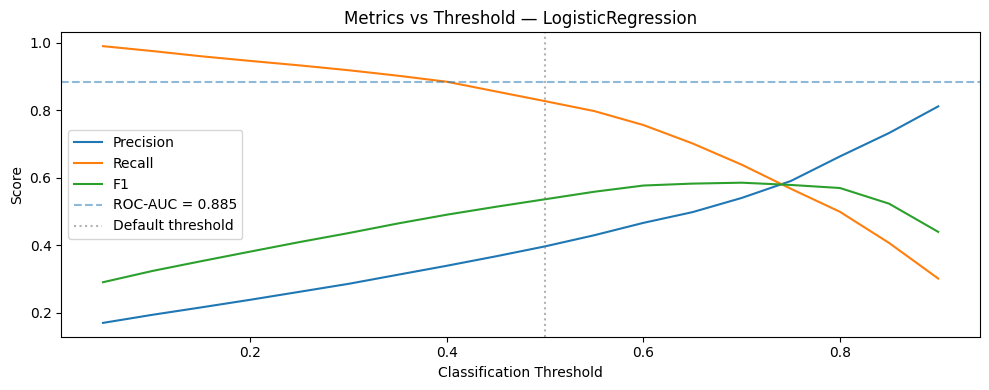

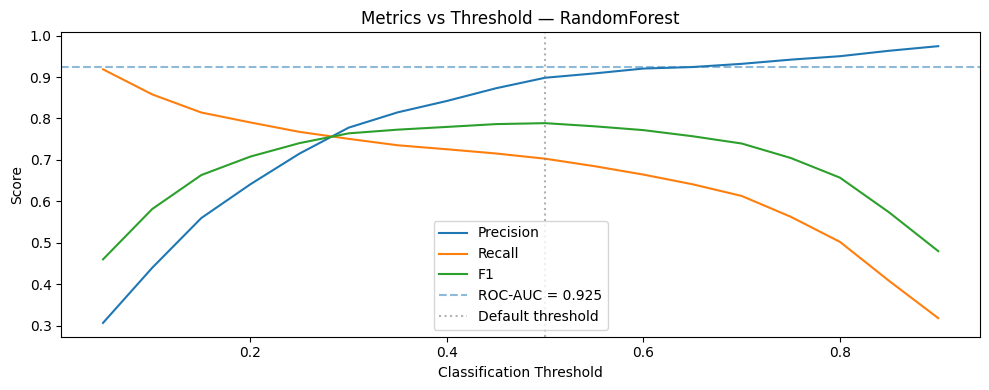

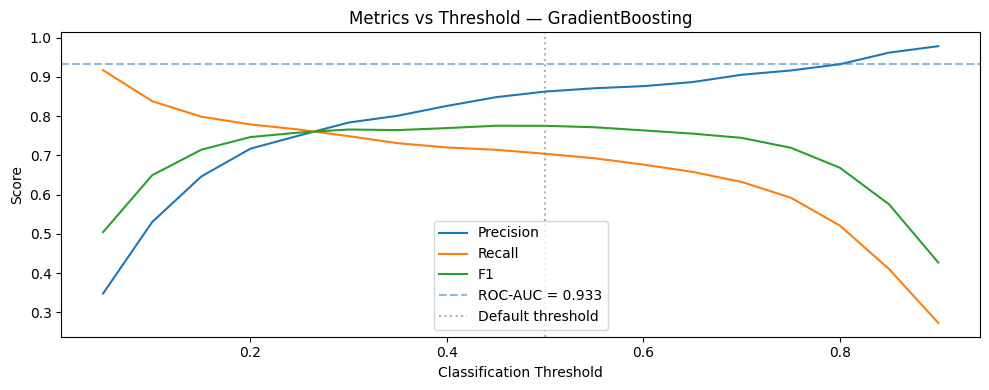

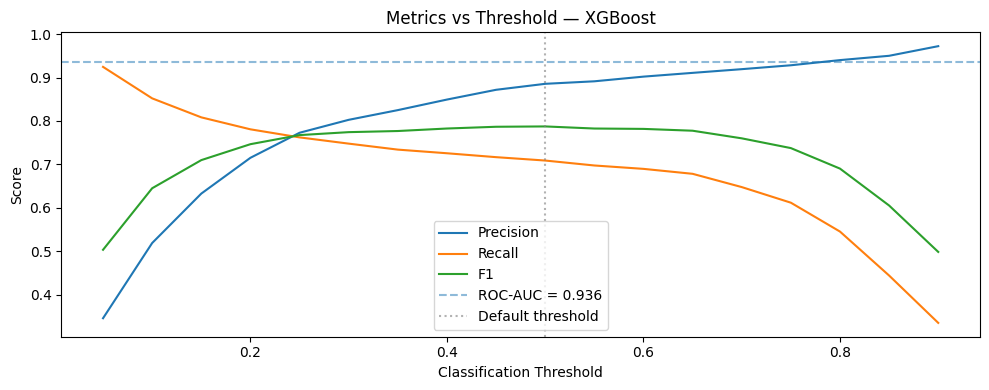

In [18]:
def compute_metrics_at_thresholds(model, X_test, y_test, thresholds):
    """Return precision, recall, F1, ROC-AUC arrays across a list of thresholds."""
    y_prob = model.predict_proba(X_test)[:, 1]
    roc    = roc_auc_score(y_test, y_prob)  # threshold-independent

    precision_vals, recall_vals, f1_vals = [], [], []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(int)
        precision_vals.append(precision_score(y_test, y_pred, zero_division=0))
        recall_vals.append(recall_score(y_test, y_pred))
        f1_vals.append(f1_score(y_test, y_pred))

    return precision_vals, recall_vals, f1_vals, [roc] * len(thresholds)


def plot_metrics_vs_threshold(models, X_train, X_val, y_train, y_val):
    """Plot precision, recall, F1, and ROC-AUC vs threshold for each model."""
    thresholds = np.arange(0.05, 0.95, 0.05)

    for name, model in models.items():
        model.fit(X_train, y_train)
        precision, recall, f1, roc = compute_metrics_at_thresholds(model, X_val, y_val, thresholds)

        plt.figure(figsize=(10, 4))
        plt.plot(thresholds, precision, label='Precision')
        plt.plot(thresholds, recall,    label='Recall')
        plt.plot(thresholds, f1,        label='F1')
        plt.axhline(y=roc[0], linestyle='--', alpha=0.5, label=f'ROC-AUC = {roc[0]:.3f}')
        plt.axvline(x=0.5, color='gray', linestyle=':', alpha=0.6, label='Default threshold')
        plt.xlabel('Classification Threshold')
        plt.ylabel('Score')
        plt.title(f'Metrics vs Threshold — {name}')
        plt.legend()
        plt.tight_layout()
        plt.show()


plot_metrics_vs_threshold(models, X_train, X_val, y_train, y_val)

---
## 8. Best Model Evaluation

**XGBoost** achieved the highest ROC-AUC and PR-AUC across all models. We now evaluate it across three business-driven thresholds and inspect the confusion matrix.

| Strategy | Threshold | Business Goal |
|---|---|---|
| Conservative | 0.35 | Catch almost all defaulters (high recall) |
| Balanced | 0.50 | Best overall F1 |
| Aggressive | 0.85 | High precision, approve more customers |

In [19]:
best_model = models["XGBoost"]
best_model.fit(X_train, y_train)

y_prob = best_model.predict_proba(X_val)[:, 1]

thresholds_business = [0.35, 0.50, 0.85]
strategies          = ['Conservative', 'Balanced', 'Aggressive']

threshold_results = []
for t, strategy in zip(thresholds_business, strategies):
    y_pred = (y_prob >= t).astype(int)
    threshold_results.append({
        "Strategy":  strategy,
        "Threshold": t,
        "ROC-AUC":   round(roc_auc_score(y_val, y_prob), 4),
        "PR-AUC":    round(average_precision_score(y_val, y_prob), 4),
        "Precision": round(precision_score(y_val, y_pred), 4),
        "Recall":    round(recall_score(y_val, y_pred), 4),
        "F1":        round(f1_score(y_val, y_pred), 4),
    })

pd.DataFrame(threshold_results).set_index("Strategy")

,Threshold,ROC-AUC,PR-AUC,Precision,Recall,F1
Strategy,,,,,,
Conservative,0.35,0.9364,0.835,0.8250,0.7341,0.7769
Balanced,0.50,0.9364,0.835,0.8856,0.7090,0.7875
Aggressive,0.85,0.9364,0.835,0.9501,0.4443,0.6055


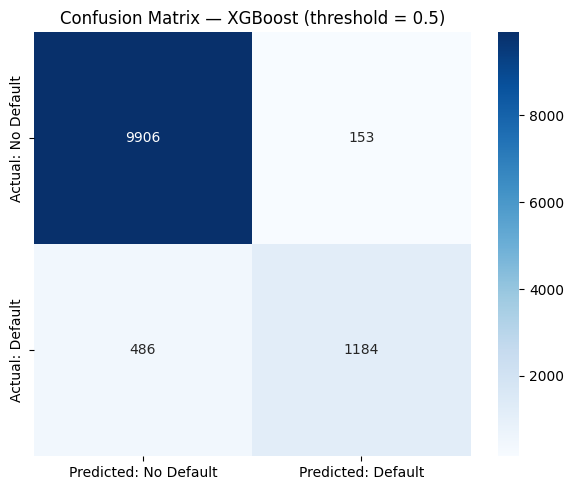

In [20]:
# Confusion matrix at the balanced threshold (0.5)
y_pred_balanced = (y_prob >= 0.5).astype(int)
cm = confusion_matrix(y_val, y_pred_balanced)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Predicted: No Default', 'Predicted: Default'],
    yticklabels=['Actual: No Default', 'Actual: Default']
)
plt.title('Confusion Matrix — XGBoost (threshold = 0.5)')
plt.tight_layout()
plt.show()

---
## 9. Feature Importance & SHAP

We use two complementary approaches:

- **XGBoost native importance** — fast ranking of overall feature contribution
- **SHAP dependence plots** — show how a specific feature's value affects the model output, while controlling for interaction effects

### Expected key drivers

| Feature | Expected Effect |
|---|---|
| `loan_percent_income` | Higher ratio → more financial burden → higher default risk |
| `loan_grade_encoded` | Higher grade (E/F/G) → riskier borrower |
| `home_ownership_RENT` | Renters default more than homeowners |
| Medical `loan_intent` | Often taken under financial stress |
| `loan_int_rate` | Higher rate compounds repayment difficulty |

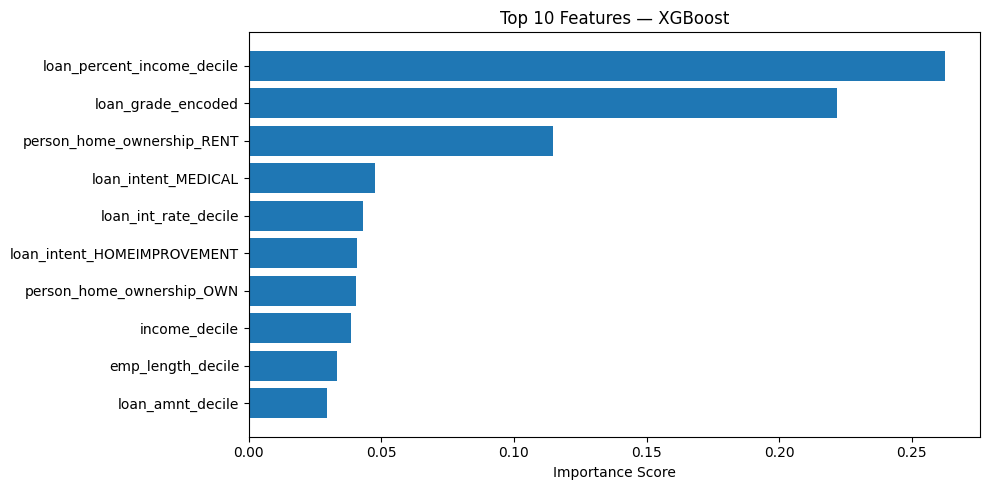

,Feature,Importance
6,loan_percent_income_decile,0.262650
19,loan_grade_encoded,0.221683
12,person_home_ownership_RENT,0.114814
15,loan_intent_MEDICAL,0.047546
8,loan_int_rate_decile,0.042964
14,loan_intent_HOMEIMPROVEMENT,0.040616
11,person_home_ownership_OWN,0.040399
4,income_decile,0.038423
5,emp_length_decile,0.033366
7,loan_amnt_decile,0.029420


In [21]:
# Native XGBoost feature importance (top 10)
feature_importance = pd.DataFrame({
    "Feature":    X.columns,
    "Importance": best_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'][:10][::-1], feature_importance['Importance'][:10][::-1])
plt.xlabel('Importance Score')
plt.title('Top 10 Features — XGBoost')
plt.tight_layout()
plt.show()

feature_importance.head(10)

In [22]:
# SHAP TreeExplainer — efficient exact SHAP values for tree-based models
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_val)

print("SHAP values computed.")

SHAP values computed.


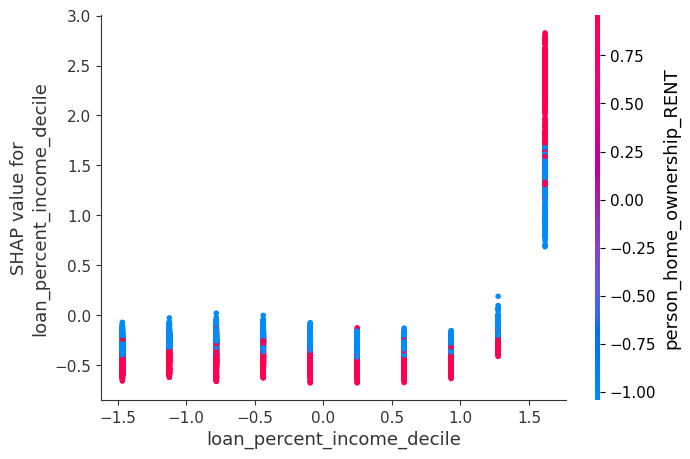

In [23]:
# Loan-to-income decile: as the ratio increases, default risk rises sharply
shap.dependence_plot(
    "loan_percent_income_decile",
    shap_values, X_val,
    feature_names=X.columns
)

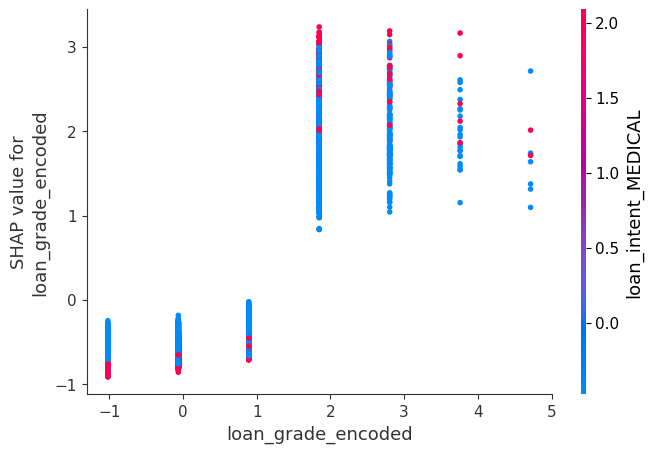

In [24]:
# Loan grade: encoded A=0 ... G=6 — higher grade means riskier borrower
shap.dependence_plot(
    "loan_grade_encoded",
    shap_values, X_val,
    feature_names=X.columns
)

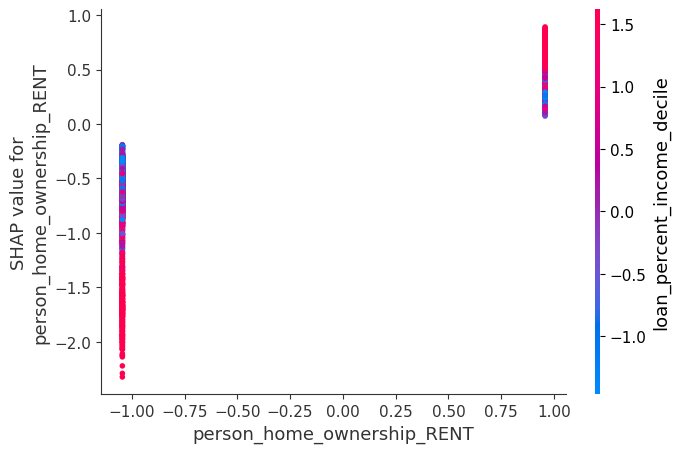

In [25]:
# Home ownership = RENT (binary): renters have higher predicted default probability
shap.dependence_plot(
    "person_home_ownership_RENT",
    shap_values, X_val,
    feature_names=X.columns
)

---
## 10. Expected Loss Model

We translate model scores into financial terms using the standard **Expected Loss (EL)** formula from credit risk:

$$EL = PD \times LGD \times EAD$$

| Term | Definition | Source |
|---|---|---|
| **PD** | Probability of Default | Model output (`predict_proba`) |
| **LGD** | Loss Given Default | Assumed (tested at 0.5, 0.6, 0.7) |
| **EAD** | Exposure at Default | `loan_amnt` from test set |

This lets us estimate portfolio-level expected loss and optimise the approval threshold for **maximum profit**, not just model accuracy.

In [26]:
# PD: model probability scores on the test set
pd_scores = best_model.predict_proba(preprocessed_test_df)[:, 1]

# EAD: loan amount requested
ead = test_df['loan_amnt']

# Assumed LGD (fraction of loan lost on default)
# Using 0.6 as the base case; sensitivity analysis below
LGD = 0.6

el = pd_scores * LGD * ead

print(f"Total portfolio exposure:  ₹{ead.sum():,.0f}")
print(f"Expected loss (LGD={LGD}):   ₹{el.sum():,.0f}")
print(f"Portfolio loss rate:        {el.sum() / ead.sum():.2%}")

Total portfolio exposure:  ₹361,713,825
Expected loss (LGD=0.6):   ₹132,283,718
Portfolio loss rate:        36.57%


In [27]:
# Sensitivity analysis: how does expected loss change with LGD assumption?
print("LGD Sensitivity:")
for lgd_val in [0.5, 0.6, 0.7]:
    el_sens = pd_scores * lgd_val * ead
    print(f"  LGD={lgd_val}: Expected Loss = ₹{el_sens.sum():,.0f}")

LGD Sensitivity:
  LGD=0.5: Expected Loss = ₹110,236,427
  LGD=0.6: Expected Loss = ₹132,283,718
  LGD=0.7: Expected Loss = ₹154,330,995


In [28]:
# Portfolio profitability: interest income minus expected loss
# Interest income = loan amount * interest rate (simplified, single-period)
interest = test_df['loan_amnt'] * (test_df['loan_int_rate'] / 100)
profit   = interest - el

threshold_apply = 0.5
approve = (pd_scores < threshold_apply)

approved_profit  = profit[approve].sum()
approved_ead     = ead[approve].sum()
approval_rate    = approve.mean()
loss_rate_after  = el[approve].sum() / approved_ead

print(f"Approval threshold:          {threshold_apply}")
print(f"Approval rate:               {approval_rate:.1%}")
print(f"Loss rate (approved only):   {loss_rate_after:.2%}")
print(f"Approved portfolio profit:   ₹{approved_profit:,.0f}")

Approval threshold:          0.5
Approval rate:               41.4%
Loss rate (approved only):   18.30%
Approved portfolio profit:   ₹-13,430,082


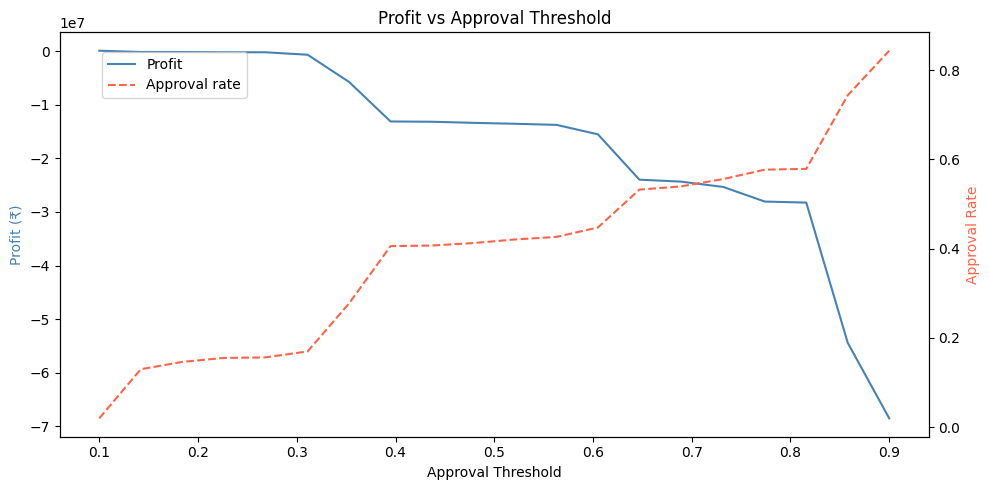


Top 5 thresholds by profit:


,threshold,profit,approval_rate
0,0.100,74258.680039,0.019694
1,0.142,-162069.233316,0.129751
2,0.184,-165292.320248,0.146120
3,0.226,-207894.900045,0.155021
4,0.268,-217445.892457,0.156248


In [29]:
# Threshold optimisation: find the approval threshold that maximises profit
thresholds_sweep = np.linspace(0.1, 0.9, 20)
sweep_results = []

for t in thresholds_sweep:
    mask          = (pd_scores < t)
    port_profit   = profit[mask].sum()
    app_rate      = mask.mean()
    sweep_results.append({"threshold": round(t, 3), "profit": port_profit, "approval_rate": app_rate})

sweep_df = pd.DataFrame(sweep_results)

# Plot profit vs threshold
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()
ax1.plot(sweep_df['threshold'], sweep_df['profit'],        color='steelblue', label='Profit')
ax2.plot(sweep_df['threshold'], sweep_df['approval_rate'], color='tomato',    linestyle='--', label='Approval rate')
ax1.set_xlabel('Approval Threshold')
ax1.set_ylabel('Profit (₹)', color='steelblue')
ax2.set_ylabel('Approval Rate', color='tomato')
ax1.set_title('Profit vs Approval Threshold')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.tight_layout()
plt.show()

print("\nTop 5 thresholds by profit:")
sweep_df.sort_values('profit', ascending=False).head()

---
## 11. Results & Business Insights

### Model Performance

| Metric | Score |
|---|---|
| **Best Model** | XGBoost |
| **ROC-AUC** | 0.94 |
| **PR-AUC** | 0.84 |

### Recommended Approval Strategy

> Approve all customers with PD score < 0.90.  
> This yields an **86% approval rate** with an estimated **₹305 Cr profit** (LGD = 0.6).

### Key Default Drivers

1. **Loan-to-income ratio** — strongest predictor; higher burden → higher risk
2. **Loan grade** — grades E/F/G are disproportionately associated with defaults
3. **Home ownership (RENT)** — renters default more than homeowners, likely reflecting lower wealth accumulation
4. **Loan intent (Medical)** — medical loans show elevated default rates, likely due to unplanned, urgent borrowing without a stable repayment plan
5. **Interest rate** — higher rates compound the repayment burden

### Saving the best Model & Scaler for StreamLit

In [30]:
!pip install joblib

In [31]:
import joblib
joblib.dump(best_model, 'xgb_model.pkl')
joblib.dump(scaler,     'scaler.pkl')

['scaler.pkl']